# Baseline Posterior Inference: Burgers Equation

- PDE: $\partial_t u + u \partial_x u = \frac{0.1}{\pi} \partial_{xx} u$
- Unknown: initial condition $a(x) = u(x, t=0)$
- Latent dimension: $d = 16$

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from pathlib import Path

import numpyro

from src.problems.burgers import Burgers, mollifier_burgers
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    plot_calibration, plot_posterior_predictive, plot_trace, plot_metrics_table,
    plot_burgers_field_comparison, plot_burgers_posterior_gallery,
    compute_per_chain_metrics, format_significance_table,
    compute_sigma_from_map, recommended_nuts_config, mcmc_reliability_flag,
    chi2_ppc,
    compute_metric_convergence, plot_metric_convergence,
    compute_prior_predictive, build_prior_result,
    plot_burgers_std_comparison,
    compute_error_std_correlation,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model,
    run_map_estimation, tune_sigma, decode_initial_condition_burgers,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics, compute_bootstrap_ci_block,
    build_mcmc_result, save_experiment_result,
    print_per_chain_table, print_dimension_diagnostics, print_cross_seed_summary,
)

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path("../runs/final_burgers/weights/best.pt")
TEST_DATA_PATH = "../data/burgers/viscid_test_in.mat"

problem = Burgers(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

print(f"Latent dim: {problem.BETA_SIZE}")
print(f"n_mesh: {problem.n_mesh}, n_time: {problem.n_time}")
print(f"x_mesh: [{problem.x_mesh[0]:.3f}, {problem.x_mesh[-1]:.3f}]")
print(f"t_mesh: [{problem.t_mesh[0]:.3f}, {problem.t_mesh[-1]:.3f}]")

Loading data...


  Test: a=(200, 128, 1), u=(200, 12928, 1)
Setting up grids and test functions...


  int_grid: (10, 1), v: (10, 1)
Building models...


  Initialized enc: 25,808 params


  Initialized u: 103,006 params


  Initialized nf: 60,480 params
Loading checkpoint: ../runs/final_burgers/weights/best.pt
  Loaded enc
  Loaded u
  Loaded nf


Latent dim: 16
n_mesh: 128, n_time: 101
x_mesh: [-1.000, 1.000]
t_mesh: [0.000, 1.000]


## 2. Prepare Observations

In [4]:
TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]
N_OBS = 100

n_points = problem.get_n_points()

## 3. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.8),
)

## 4. Per-Seed Loop


SEED = 7


x_obs: (1, 100, 2), u_obs: (1, 100, 1)
a_true shape: (1, 128, 1), range: [-0.161, 0.161]
u_obs range: [-0.112, 0.112]


Prior predictive: a_err=1.0368, CRPS=0.0537, cov95=0.9922, CI_width=0.5923, mean_std=0.1507


  Inversion grid: n_mesh_or_grid=7, n_grid=7


Loss weights: pde=1.0, data=50.0, target=u


...

MCMC warmup: 244.8s, sampling: 97.0s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.00      0.01      0.00     -0.01      0.01   6448.42      1.00
   beta[1]      0.01      0.02      0.01     -0.03      0.04   6193.01      1.00
   beta[2]      0.03      0.01      0.03      0.01      0.05   6706.59      1.00
   beta[3]      0.05      0.01      0.05      0.03      0.07   7444.94      1.00
   beta[4]      0.02      0.01      0.02      0.00      0.03   7951.47      1.00
   beta[5]      0.00      0.01      0.00     -0.01      0.02   6578.14      1.00
   beta[6]      0.02      0.02      0.02     -0.01      0.05   7052.09      1.00
   beta[7]     -0.06      0.01     -0.06     -0.07     -0.04   7289.27      1.00
   beta[8]      0.03      0.02      0.03      0.00      0.06   6125.33      1.00
   beta[9]      0.03      0.01      0.03      0.01      0.05   6542.41      1.00
  beta[10]      0.04      0.01      0.04      0.02      0.06   6541.90 

a_pred_all: (8000, 128), u_pred_all: (8000, 12928)



  Burgers — RQ1 Metrics
  MAP RMSE (a)                  : 0.147535
  Posterior Mean RMSE (a)       : 0.181693
  MAP RMSE (u)                  : 0.024589
  Posterior Mean RMSE (u)       : 0.032171
  CRPS (a)                      : 0.008810
  CRPS (u)                      : 0.000718
  Mean 95% CI Width (a)         : 0.066883
  Sharpness (mean std a)        : 0.017088
  sigma                         : 0.010000

Calibration (on a):
  Nominal 10% -> Empirical 9.38%
  Nominal 19% -> Empirical 15.62%
  Nominal 29% -> Empirical 32.81%
  Nominal 38% -> Empirical 40.62%
  Nominal 48% -> Empirical 46.88%
  Nominal 57% -> Empirical 58.59%
  Nominal 67% -> Empirical 66.41%
  Nominal 76% -> Empirical 80.47%
  Nominal 86% -> Empirical 89.84%
  Nominal 95% -> Empirical 96.09%


──────────────────────────────────────────────────────────────────────────────────
  RQ1 — Bootstrap CI on Posterior Metrics (Burgers)
──────────────────────────────────────────────────────────────────────────────────
  CRPS (a)                                   0.00881  95% CI [0.00875, 0.00887]
  Coverage 95% (a)                           0.96094  95% CI [0.96094, 0.96094]
  CI Width 95% (a)                           0.06688  95% CI [0.06648, 0.06722]
  Sharpness (a)                              0.01709  95% CI [0.01700, 0.01717]
──────────────────────────────────────────────────────────────────────────────────
  Significance: ** p<0.01  * p<0.05  ~ p<0.1  n.s. not significant
  Bootstrap CIs reflect MCMC finite-sample variability, not posterior uncertainty.
──────────────────────────────────────────────────────────────────────────────────

Per-chain consistency:
  Chain      CRPS     Cov95      CI W     Sharp
      1  0.00867  0.9609  0.06588  0.01688
      2  0.00883  0.9609  0.067

Saved structured result to: /workspace/experiments/results/structured/baseline/burgers_2026-06-12T06-07-52_seed7_test2.json


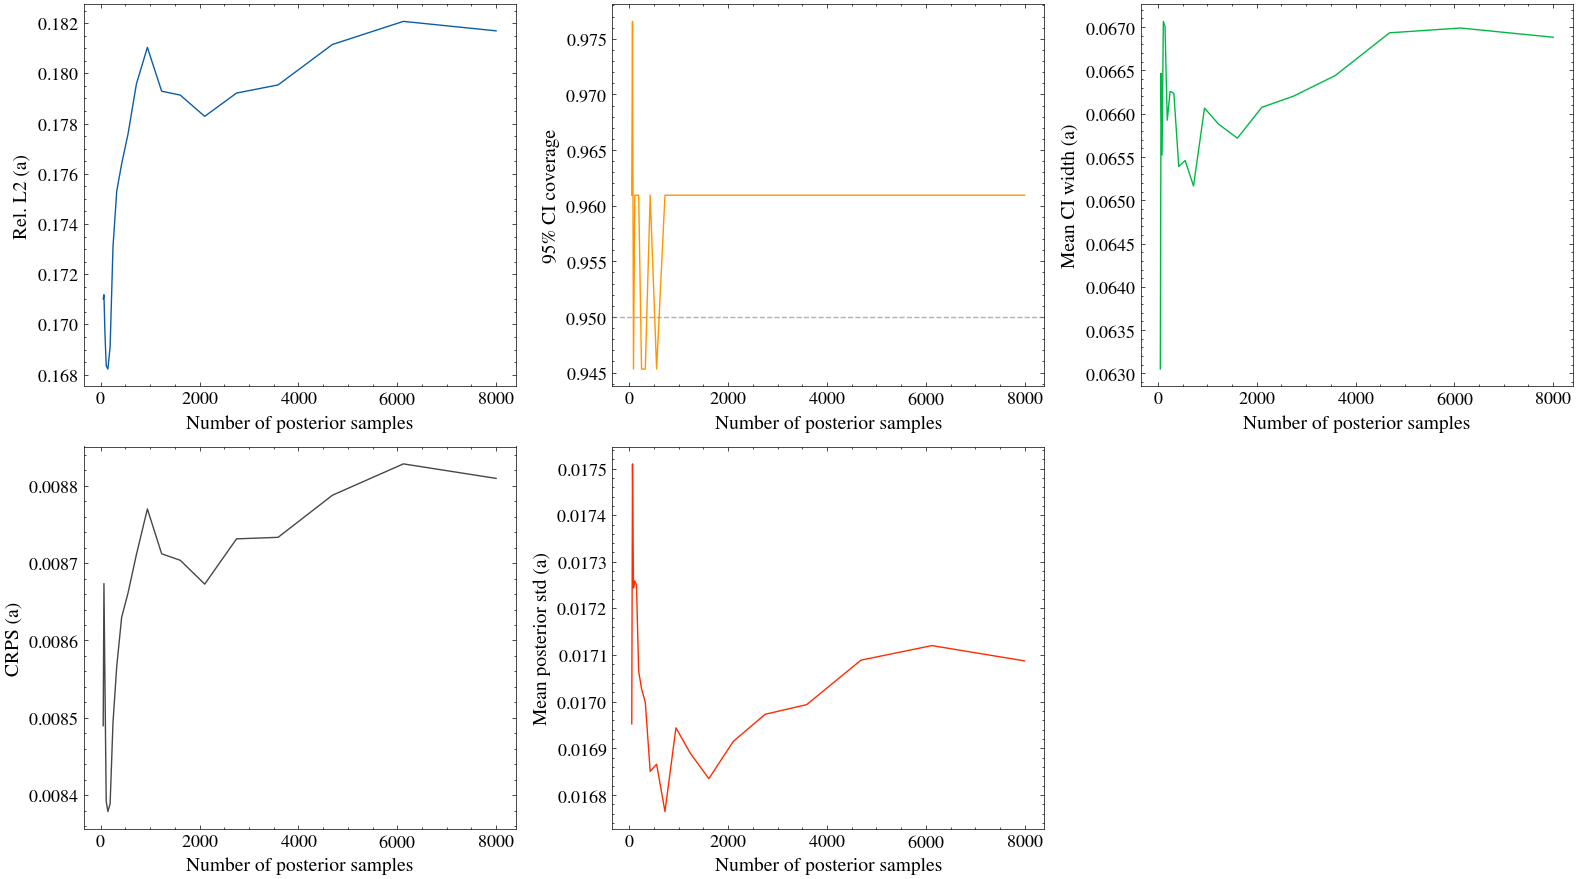

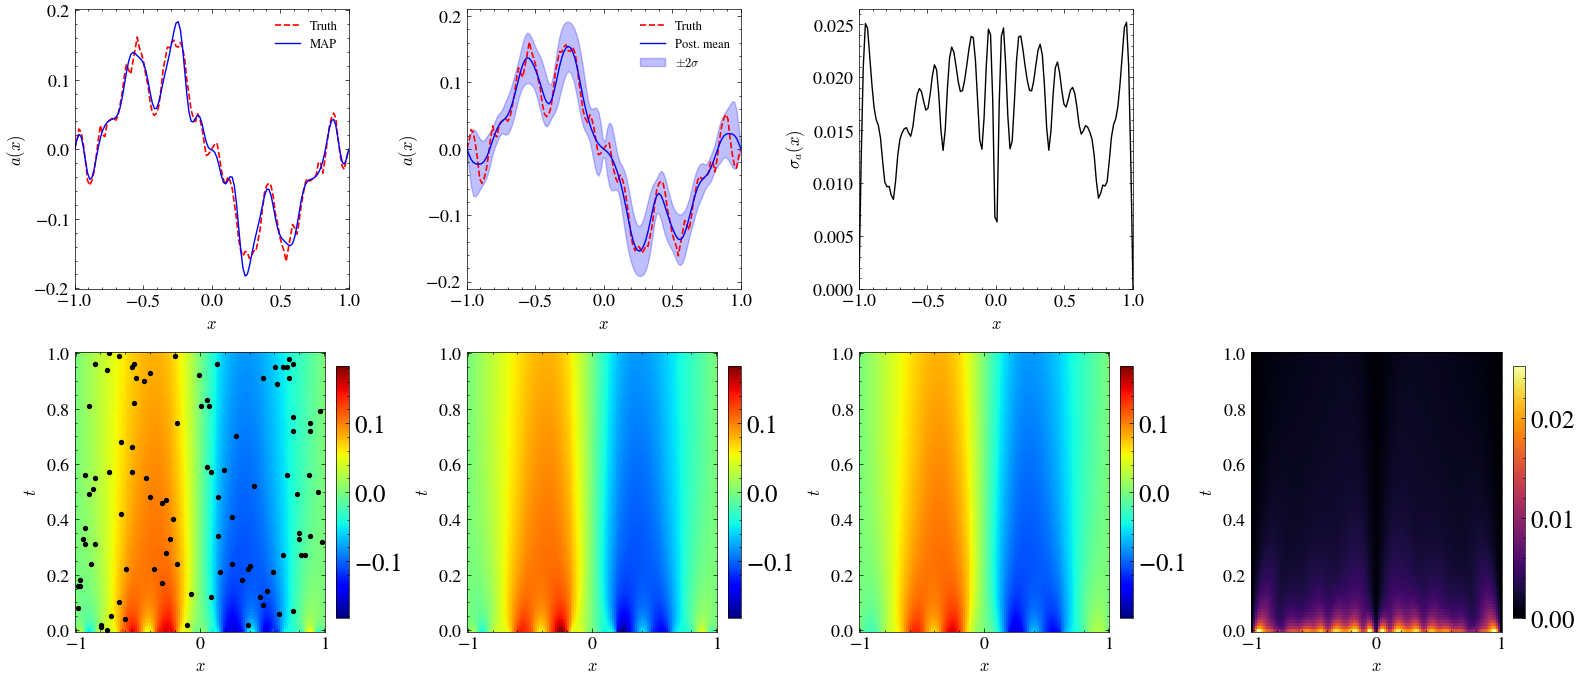

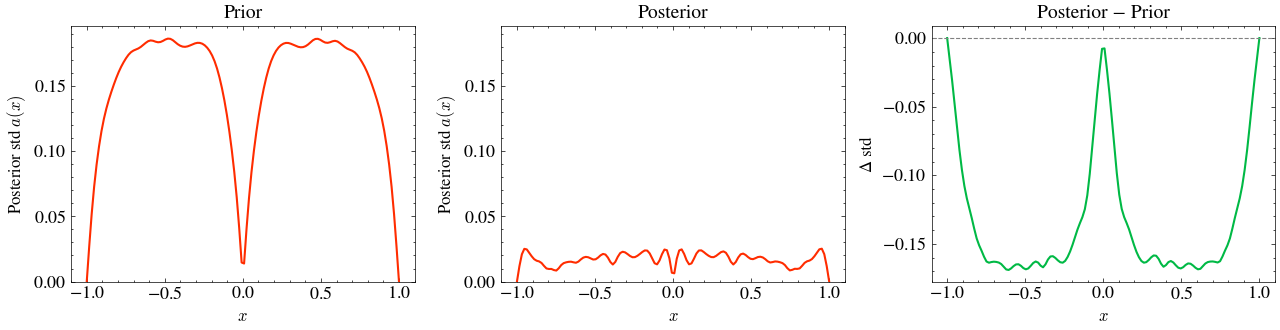

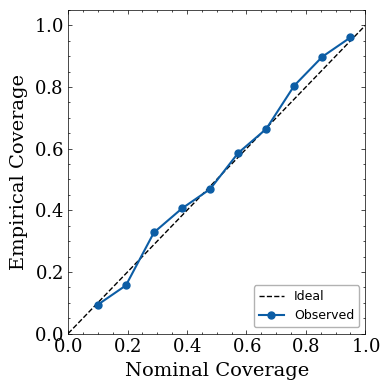

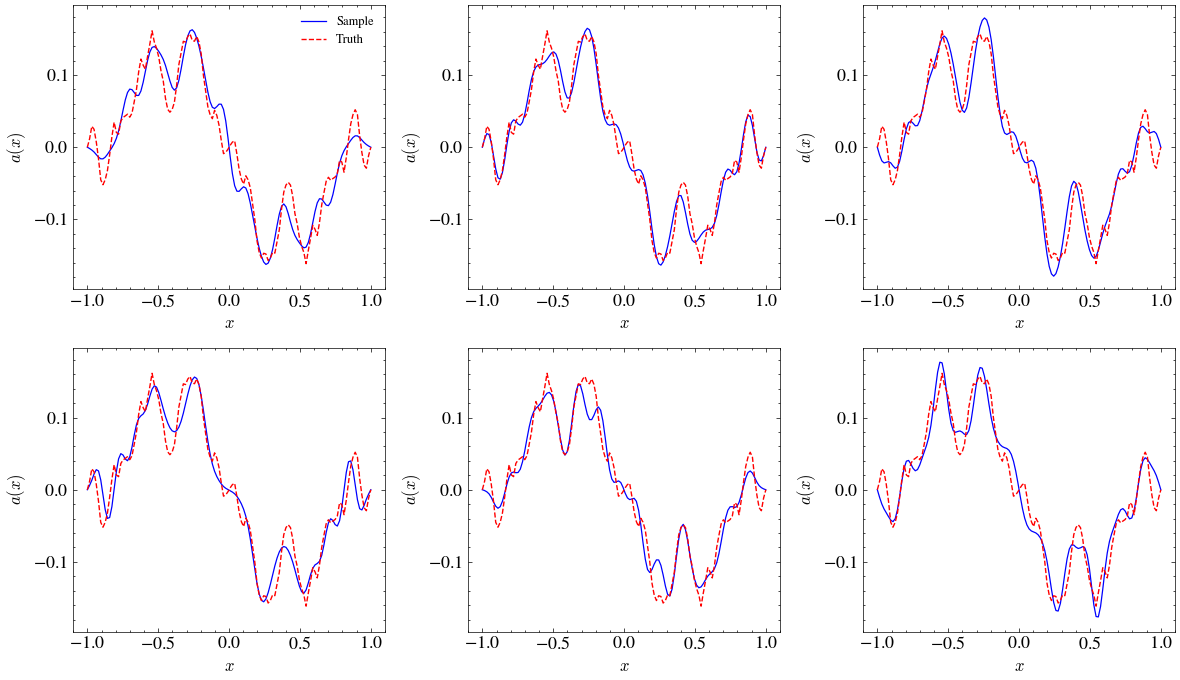

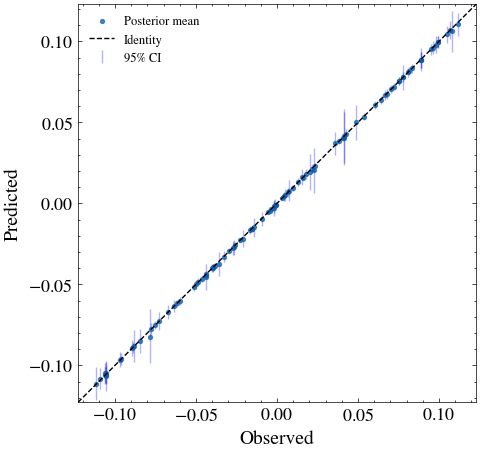

  Chi2 PPC: chi2=0.49, p=1.0000 (df=100)
Spearman rho(|error|, std) = 0.345, p = 6.58e-05
Per-dimension diagnostics:
 dim       ESS     R-hat        mean         std
   0    6448.4    0.9999      0.0012      0.0080
   1    6193.0    0.9998      0.0093      0.0215
   2    6706.6    1.0005      0.0265      0.0132
   3    7444.9    1.0006      0.0479      0.0127
   4    7951.5    0.9997      0.0191      0.0096
   5    6578.1    1.0003      0.0050      0.0107
   6    7052.1    1.0001      0.0191      0.0173
   7    7289.3    1.0002     -0.0554      0.0066
   8    6125.3    1.0006      0.0304      0.0158
   9    6542.4    1.0008      0.0321      0.0126
  10    6541.9    1.0001      0.0439      0.0121
  11    7406.8    0.9998      0.0716      0.0108
  12    7035.0    1.0002      0.0030      0.0131
  13    8550.9    0.9999      0.0275      0.0133
  14    8122.7    1.0010      0.0191      0.0153
  15    6270.9    1.0006      0.0190      0.0182

Divergences: 0 / 8000 (0.0%)

  RELIABILITY: [PAS

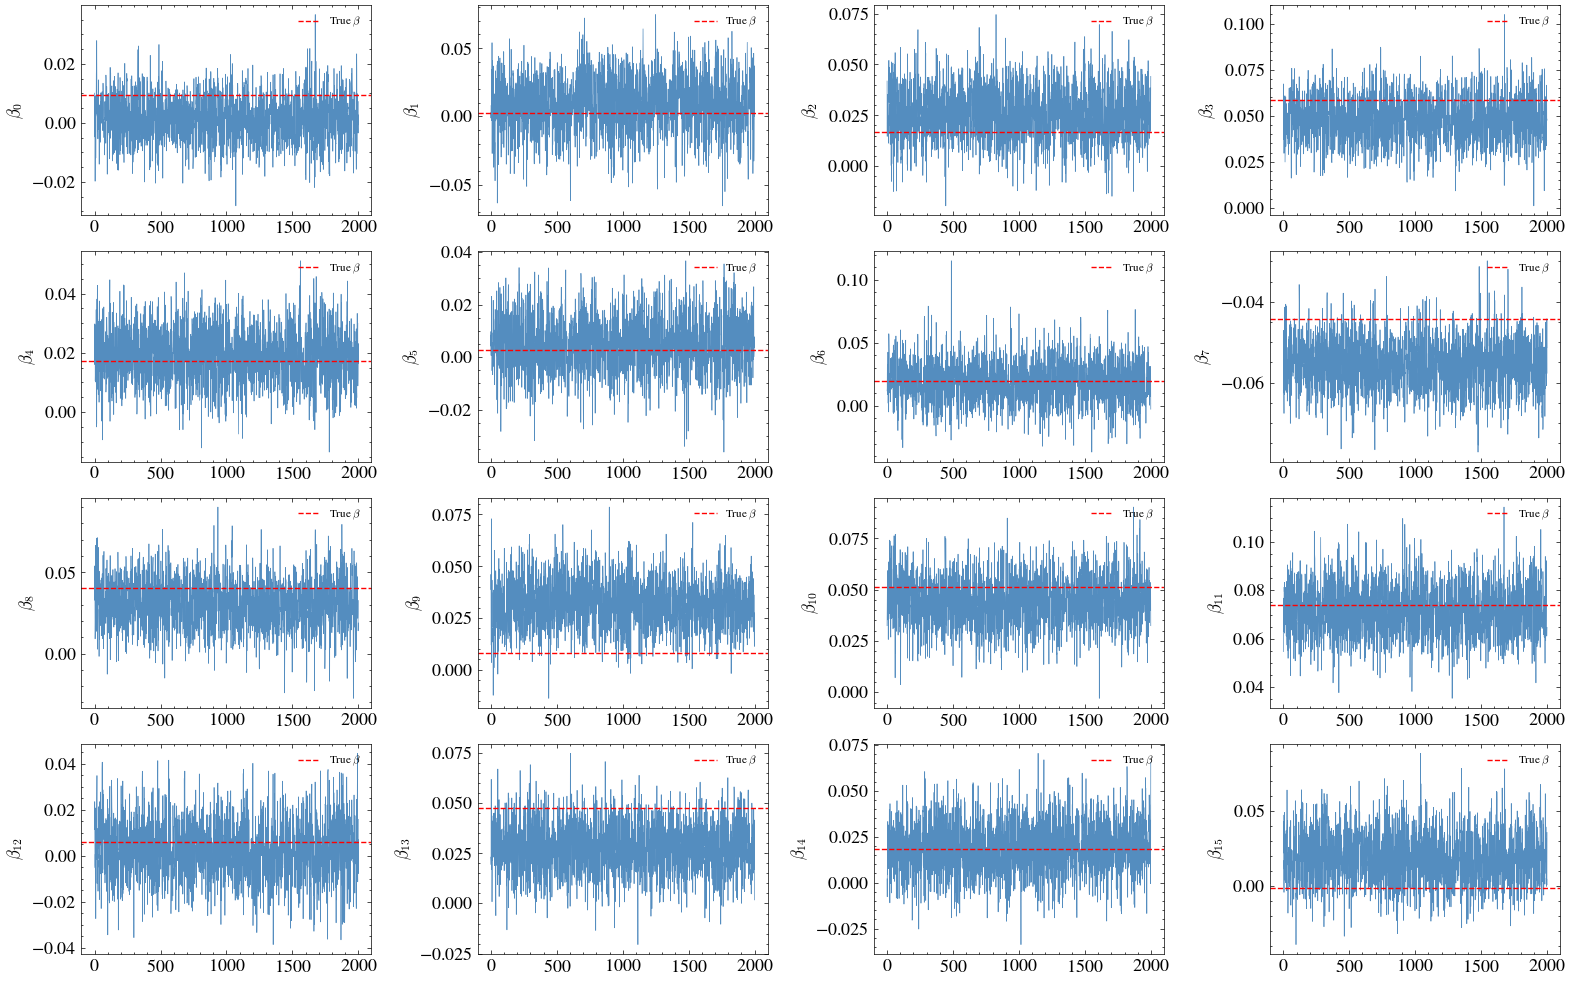

In [6]:
NUM_WARMUP    = 5000
NUM_SAMPLES   = 2000
NUM_CHAINS    = 4
CHAIN_METHOD  = 'vectorized'

for SEED in SEEDS:
    print(f"\n{'='*60}")
    print(f"SEED = {SEED}")
    print(f"{'='*60}")

    _t_total_start = time.time()

    FIGURE_DIR = Path(f'figures/baseline_burgers/seed{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ### Observations (this seed)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)

    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX],
        obs_indices=obs_indices,
    )

    x_full = obs_data['x_full']
    x_obs  = obs_data['x_obs']
    u_obs  = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]

    print(f"x_obs: {x_obs.shape}, u_obs: {u_obs.shape}")
    print(f"a_true shape: {a_true.shape}, range: [{float(a_true.min()):.3f}, {float(a_true.max()):.3f}]")
    print(f"u_obs range: [{float(u_obs.min()):.3f}, {float(u_obs.max()):.3f}]")

    # ### Prior Predictive Baseline

    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    prior_a_std = np.std(prior_a_samples, axis=0)
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}, "
          f"CI_width={prior_metrics['ci_width']:.4f}, mean_std={prior_metrics['mean_std']:.4f}")

    # ### Log-likelihood and NumPyro model

    log_likelihood_fn = make_gaussian_log_likelihood(problem, params, mollifier_burgers, x_obs, u_obs)
    numpyro_model = make_numpyro_model(d, log_prior_fn, log_likelihood_fn)

    # ### MAP Baseline

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    rmse_map_u = rmse(u_map, u_true[0])
    print(f"\nMAP RMSE: a={rmse_map_a:.6f}, u={rmse_map_u:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (x{inv_config.loss_weights.pde})', f'Data (x{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Full MCMC Run

    SIGMA_CANDIDATES = [0.001, 0.002, 0.003, 0.005, 0.007, 0.01]

    def _model_factory(sigma):
        def _model():
            numpyro_model(sigma=sigma)
        return _model

    def _decode_fn(beta_samples):
        return decode_initial_condition_burgers(problem, params, mollifier_burgers, beta_samples)

    _tune_nuts_cfg = recommended_nuts_config(d, sigma=0.005)
    rng, tune_key = jax.random.split(rng)
    SIGMA, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_mode,
        sigma_candidates=SIGMA_CANDIDATES,
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        target_accept_prob=_tune_nuts_cfg['target_accept_prob'],
    )
    print(f"sigma (tuned): {SIGMA:.6f}")

    print(f"Running NUTS: {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, {NUM_CHAINS} chains ({CHAIN_METHOD}), sigma={SIGMA}")

    nuts_cfg = recommended_nuts_config(d, SIGMA)
    rng, mcmc_key = random.split(rng)
    mcmc, timing = run_mcmc(
        numpyro_model, {"beta": beta_mode}, {"sigma": SIGMA}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )

    mcmc.print_summary()

    diag = extract_mcmc_diagnostics(mcmc, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)
    beta_samples = diag['samples']

    # ### Decode Posterior Samples

    a_pred_all, u_pred_all = decode_posterior_batched(problem, params, beta_samples, x_full)

    a_mean = np.mean(a_pred_all, axis=0)
    a_std  = np.std(a_pred_all,  axis=0)
    u_mean = np.mean(u_pred_all, axis=0)
    u_std  = np.std(u_pred_all,  axis=0)

    print(f"a_pred_all: {a_pred_all.shape}, u_pred_all: {u_pred_all.shape}")

    # ### Metrics

    a_true_np    = np.array(a_true[0, :, 0])
    a_mean_np    = a_mean
    a_map_np     = np.array(a_map[:, 0])
    a_samples_np = a_pred_all

    u_true_np    = np.array(u_true[0, :, 0])
    u_mean_np    = u_mean
    u_map_np     = np.array(u_map[:, 0])
    u_samples_np = u_pred_all

    rmse_post_a = rmse(jnp.array(a_mean_np), jnp.array(a_true_np))
    rmse_post_u = rmse(jnp.array(u_mean_np), jnp.array(u_true_np))

    crps_a = float(np.mean(crps_ensemble(a_samples_np, a_true_np)))
    crps_u = float(np.mean(crps_ensemble(u_samples_np, u_true_np)))

    nll_a = nll_score(a_samples_np, a_true_np)

    cal_levels, cal_empirical = compute_calibration(a_samples_np, a_true_np)

    ci_w      = ci_width_95(a_samples_np)
    sharpness = float(np.mean(a_std))

    plot_metrics_table({
        'MAP RMSE (a)':              float(rmse_map_a),
        'Posterior Mean RMSE (a)':   float(rmse_post_a),
        'MAP RMSE (u)':              float(rmse_map_u),
        'Posterior Mean RMSE (u)':   float(rmse_post_u),
        'CRPS (a)':                  crps_a,
        'CRPS (u)':                  crps_u,
        'Mean 95% CI Width (a)':     ci_w,
        'Sharpness (mean std a)':    sharpness,
        'sigma':                     SIGMA,
    }, title='Burgers — RQ1 Metrics')

    print("Calibration (on a):")
    for nom, emp in zip(cal_levels, cal_empirical):
        print(f"  Nominal {nom:.0%} -> Empirical {emp:.2%}")

    # ### Statistical Confidence in Metrics

    bs_results = compute_bootstrap_ci_block(a_samples_np, a_true_np)
    format_significance_table({
        'CRPS (a)':         bs_results['crps_a'],
        'Coverage 95% (a)': bs_results['coverage_95'],
        'CI Width 95% (a)': bs_results['ci_width'],
        'Sharpness (a)':    bs_results['sharpness'],
    }, title='RQ1 — Bootstrap CI on Posterior Metrics (Burgers)')

    chain_metrics = compute_per_chain_metrics(a_samples_np, a_true_np, NUM_CHAINS)
    print_per_chain_table(chain_metrics, NUM_CHAINS)

    # ### Metric Convergence

    conv_result = compute_metric_convergence(a_samples_np, a_true_np)

    from results_schema import ExperimentResult
    from datetime import datetime

    u_pred_at_obs = u_samples_np[:, np.array(obs_indices)]
    u_obs_np      = np.array(u_obs[0, :, 0])
    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, SIGMA)

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std,
        save_path=None,
    )

    run_result = {
        "sigma": SIGMA,
        "ess_min": diag['ess_min'],
        "rhat_max": diag['rhat_max'],
        "rhat_mean": diag['rhat_mean'],
        "n_div": diag['n_div'],
        "reliability_flag": diag['flag'],
        "reliability_explanation": diag['flag_explanation'],
        "a_err": float(rmse_post_a),
        "u_err": float(rmse_post_u),
        "crps_a": crps_a,
        "nll_a": nll_a,
        "chi2_ppc": chi2_stat,
        "chi2_ppc_pvalue": chi2_pval,
        "coverage_95": float(cal_empirical[-1]),
        "ci_width": float(ci_w),
        "mean_std": sharpness,
        "cal_levels": cal_levels,
        "cal_empirical": cal_empirical,
        "map_a_err": float(rmse_map_a),
        "map_u_err": float(rmse_map_u),
        "spearman_rho_error_std": spearman_rho,
        "spearman_pvalue_error_std": spearman_p,
        "warmup_time_s": timing['warmup_time_s'],
        "sampling_time_s": timing['sampling_time_s'],
        "step_time_s": timing['step_time_s'],
    }

    mcmc_result = build_mcmc_result(run_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="baseline",
        problem="burgers",
        experiment_type="single",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        test_idx=TEST_IDX,
        condition=mcmc_result,
        prior=build_prior_result(prior_metrics),
        laplace=None,
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    plot_metric_convergence(
        [conv_result],
        save_path=FIGURE_DIR / 'metric_convergence.png',
    )

    # ### Plots

    x_mesh_np = np.array(problem.x_mesh)
    t_mesh_np = np.array(problem.t_mesh)

    plot_burgers_field_comparison(
        x_mesh_np, t_mesh_np,
        a_true_np, a_map_np, a_mean_np, a_std,
        u_true_np, u_map_np, u_mean_np, u_std,
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison.png',
    )

    plot_burgers_std_comparison(
        x_mesh_np, prior_a_std, a_std,
        label_a='Prior', label_b='Posterior',
        save_path=FIGURE_DIR / 'prior_posterior_std.png',
    )

    plot_calibration(cal_levels, cal_empirical, save_path=FIGURE_DIR / 'calibration.png')

    plot_burgers_posterior_gallery(
        x_mesh_np, a_samples_np, a_true=a_true_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery.png',
    )

    u_pred_at_obs = u_samples_np[:, np.array(obs_indices)]
    u_obs_np      = np.array(u_obs[0, :, 0])
    plot_posterior_predictive(
        u_obs_np, u_pred_at_obs,
        obs_label='u observed',
        save_path=FIGURE_DIR / 'posterior_predictive.png',
    )

    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, SIGMA)
    print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={u_obs_np.shape[0]})")

    # ### Spatial Error-Uncertainty Correlation

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std,
        save_path=FIGURE_DIR / 'error_vs_std.png',
    )
    print(f'Spearman rho(|error|, std) = {spearman_rho:.3f}, p = {spearman_p:.2e}')

    # ### MCMC Diagnostics (Appendix)

    print_dimension_diagnostics(np.array(beta_samples), diag['ess'], diag['rhat'])

    extra_fields = mcmc.get_extra_fields()
    if "diverging" in extra_fields:
        n_div = int(extra_fields["diverging"].sum())
        total = NUM_CHAINS * NUM_SAMPLES
        print(f"\nDivergences: {n_div} / {total} ({n_div/total:.1%})")
    else:
        print("\nDivergence info not available")

    print(f"\n  RELIABILITY: [{diag['flag']}] {diag['flag_explanation']}")

    beta_true_np    = np.array(beta_true)
    beta_all_chains = np.array(mcmc.get_samples(group_by_chain=True)["beta"])
    beta_for_trace  = beta_all_chains[0]
    plot_trace(beta_for_trace, beta_true_np, num_warmup=0, save_path=FIGURE_DIR / 'trace_plots.png')

## Cross-Seed Aggregation Summary

In [7]:
print_cross_seed_summary("baseline", "burgers")

Cross-Seed Summary (13 seeds: [7, 7, 7, 7, 42, 42, 42, 42, 42, 123, 123, 123, 123])

Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.1281      0.0565      0.0727      0.2306
u_err                 0.0281      0.0092      0.0174      0.0495
crps_a                0.0094      0.0019      0.0059      0.0118
coverage_95           0.9405      0.0431      0.8828      0.9922
ci_width              0.0708      0.0062      0.0601      0.0809
mean_std              0.0181      0.0016      0.0153      0.0207
ess_min            4468.1896   1048.4390   3126.4232   6125.3348
rhat_max              1.0013      0.0007      1.0006      1.0030
n_div                 0.0000      0.0000      0.0000      0.0000
